# Late Delivery Prediction: DataCo Supply Chain

Predicting whether an order will be delivered late, using only information known
at order time.

**Goal:** flag high-risk orders before they ship, so the business can act
(warn the customer, upgrade shipping, prioritize fulfilment) instead of only
reporting lateness after the fact.

**Approach:** logistic regression on order-time features only. Outcome columns
(`delivery_status`, `days_shipping_real`) are deliberately excluded to prevent
data leakage.

**Result:** ~70% accuracy, well above the 55% base rate. The model independently
confirms the main finding from the dashboard analysis: shipping mode is by far
the strongest driver of late delivery, with First Class the biggest risk.

In [1]:
import pandas as pd
import numpy as np
import sklearn

## 1. Load and join the data

In [2]:
# load the cleaned star-schema tables produced by the ETL
fact = pd.read_csv("fact_order_items.csv")
dim_order = pd.read_csv("dim_order.csv")
dim_customer = pd.read_csv("dim_customer.csv")
dim_category = pd.read_csv("dim_category.csv")

In [3]:
# join the fact table to the dimensions we need, so market, segment,
# and category are available as readable columns instead of just IDs
df = fact.merge(dim_order[["order_id", "market"]], on="order_id", how="left")
df = df.merge(dim_customer[["customer_id", "customer_segment"]], on="customer_id", how="left")
df = df.merge(dim_category[["category_id", "category_name"]], on="category_id", how="left")

print("combined shape:", df.shape)
print(df[["shipping_mode", "market", "customer_segment", "category_name", "delivery_status"]].head())

combined shape: (180519, 27)
    shipping_mode        market customer_segment   category_name  \
0  Standard Class  Pacific Asia         Consumer  Sporting Goods   
1  Standard Class  Pacific Asia         Consumer  Sporting Goods   
2  Standard Class  Pacific Asia         Consumer  Sporting Goods   
3  Standard Class  Pacific Asia      Home Office  Sporting Goods   
4  Standard Class  Pacific Asia        Corporate  Sporting Goods   

    delivery_status  
0  Advance shipping  
1     Late delivery  
2  Shipping on time  
3  Advance shipping  
4  Advance shipping  


## 2. Define the target and features

The target is whether an order was delivered late. Features use only information available at order time. `delivery_status` and `days_shipping_real` are excluded to prevent data leakage, since they describe the outcome and would not exist when a new order is placed.

In [4]:
# target variable: 1 if the order was delivered late, otherwise 0
df["is_late"] = (df["delivery_status"] == "Late delivery").astype(int)

# feature set. only variables known at order time.
# delivery_status and days_shipping_real are excluded to prevent data leakage,
# since they describe the outcome and won't exist when a new order is placed.
features = [
    "shipping_mode",
    "days_shipping_scheduled",
    "market",
    "customer_segment",
    "category_name",
    "order_item_quantity",
    "order_item_discount_rate",
    "order_item_product_price",
]

X = df[features]
y = df["is_late"]

print("late rate overall:", round(y.mean() * 100, 1), "%")
print("features used:", len(features))
print(X.head())

late rate overall: 54.8 %
features used: 8
    shipping_mode  days_shipping_scheduled        market customer_segment  \
0  Standard Class                        4  Pacific Asia         Consumer   
1  Standard Class                        4  Pacific Asia         Consumer   
2  Standard Class                        4  Pacific Asia         Consumer   
3  Standard Class                        4  Pacific Asia      Home Office   
4  Standard Class                        4  Pacific Asia        Corporate   

    category_name  order_item_quantity  order_item_discount_rate  \
0  Sporting Goods                    1                      0.04   
1  Sporting Goods                    1                      0.05   
2  Sporting Goods                    1                      0.06   
3  Sporting Goods                    1                      0.07   
4  Sporting Goods                    1                      0.09   

   order_item_product_price  
0                    327.75  
1                    327.

## 3. Train / test split

Holding back 20% of orders to measure performance on data the model never saw during training.

In [5]:
from sklearn.model_selection import train_test_split

# hold back 20% as a test set the model never sees during training,
# so we can measure performance on unseen orders
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

## 4. Train the model

Logistic regression, with the text columns one-hot encoded inside a pipeline.

In [6]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# text columns need to be converted to numbers before modeling
categorical = ["shipping_mode", "market", "customer_segment", "category_name"]

preprocess = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical)],
    remainder="passthrough"
)

# logistic regression predicts a yes/no outcome (late or not)
model = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000))
])

# train the model on the training set
model.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 5. Evaluate on unseen orders

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# predict on the held-out test set (orders the model never saw)
y_pred = model.predict(X_test)

print("accuracy:", round(accuracy_score(y_test, y_pred) * 100, 1), "%")
print()
print("confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["on time", "late"]))

accuracy: 69.7 %

confusion matrix:
[[14414  1894]
 [ 9056 10740]]

              precision    recall  f1-score   support

     on time       0.61      0.88      0.72     16308
        late       0.85      0.54      0.66     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.71      0.69     36104
weighted avg       0.74      0.70      0.69     36104



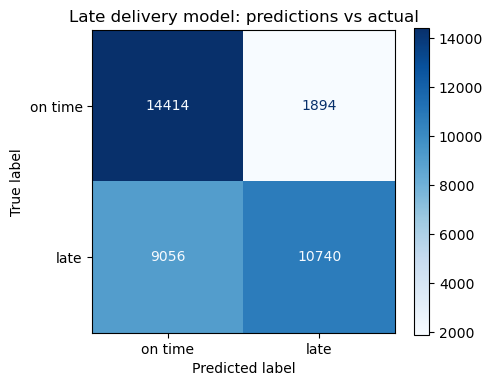

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# show the confusion matrix as a labeled heatmap for readability
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["on time", "late"],
    cmap="Blues",
    ax=ax
)
ax.set_title("Late delivery model: predictions vs actual")
plt.tight_layout()
plt.show()

## 6. What drives the prediction

The model's feature weights. A positive weight pushes toward a late prediction, a negative weight toward on time.

In [9]:
# see which features the model leaned on most
feature_names = model.named_steps["prep"].get_feature_names_out()
weights = model.named_steps["clf"].coef_[0]

importance = pd.DataFrame({"feature": feature_names, "weight": weights})

print("top features pushing toward LATE:")
print(importance.sort_values("weight", ascending=False).head(6)[["feature", "weight"]].to_string(index=False))
print()
print("top features pushing toward ON TIME:")
print(importance.sort_values("weight").head(6)[["feature", "weight"]].to_string(index=False))

top features pushing toward LATE:
                          feature   weight
   cat__shipping_mode_First Class 2.180844
  cat__shipping_mode_Second Class 0.505402
cat__customer_segment_Home Office 0.230531
   cat__customer_segment_Consumer 0.225492
  cat__customer_segment_Corporate 0.212382
      cat__category_name_Lacrosse 0.155379

top features pushing toward ON TIME:
                               feature    weight
           cat__shipping_mode_Same Day -1.178921
     cat__shipping_mode_Standard Class -0.838920
    remainder__days_shipping_scheduled -0.164032
   cat__category_name_Men's Golf Clubs -0.156506
           cat__category_name_Cameras  -0.095592
cat__category_name_Baseball & Softball -0.083548


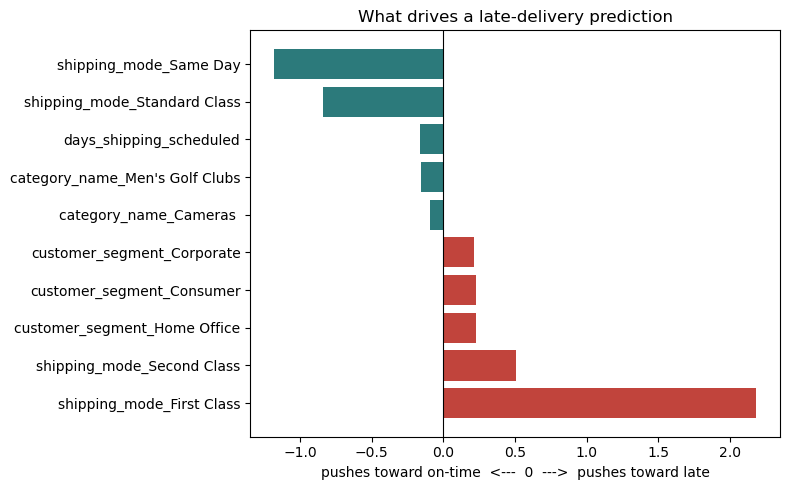

In [10]:
# show which features push most toward a "late" prediction
importance_sorted = importance.sort_values("weight", ascending=False)
top = pd.concat([importance_sorted.head(5), importance_sorted.tail(5)])

# clean up the long feature names for the chart labels
top["label"] = top["feature"].str.replace("cat__", "").str.replace("remainder__", "")

colors = ["#C1443C" if w > 0 else "#2C7A7B" for w in top["weight"]]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top["label"], top["weight"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("What drives a late-delivery prediction")
ax.set_xlabel("pushes toward on-time  <---  0  --->  pushes toward late")
plt.tight_layout()
plt.show()

## 7. Threshold tuning

The model outputs a probability of lateness. Lowering the decision threshold flags more orders as late, which catches more of the truly late ones (higher recall) at the cost of more false alarms (lower precision). The right threshold depends on the cost of a missed late order versus a false alarm.

In [11]:
from sklearn.metrics import recall_score, precision_score

# get the model's predicted probability of "late" for each test order
late_probability = model.predict_proba(X_test)[:, 1]

# compare the default 0.50 cutoff against a lower 0.35 cutoff
for threshold in [0.50, 0.40, 0.35, 0.30]:
    flagged_late = (late_probability >= threshold).astype(int)
    rec = recall_score(y_test, flagged_late)
    prec = precision_score(y_test, flagged_late)
    print(f"threshold {threshold:.2f}  ->  catches {rec*100:4.1f}% of late orders   |   {prec*100:4.1f}% of flags are correct")

threshold 0.50  ->  catches 54.3% of late orders   |   85.0% of flags are correct
threshold 0.40  ->  catches 60.3% of late orders   |   77.5% of flags are correct
threshold 0.35  ->  catches 99.9% of late orders   |   54.9% of flags are correct
threshold 0.30  ->  catches 100.0% of late orders   |   54.8% of flags are correct


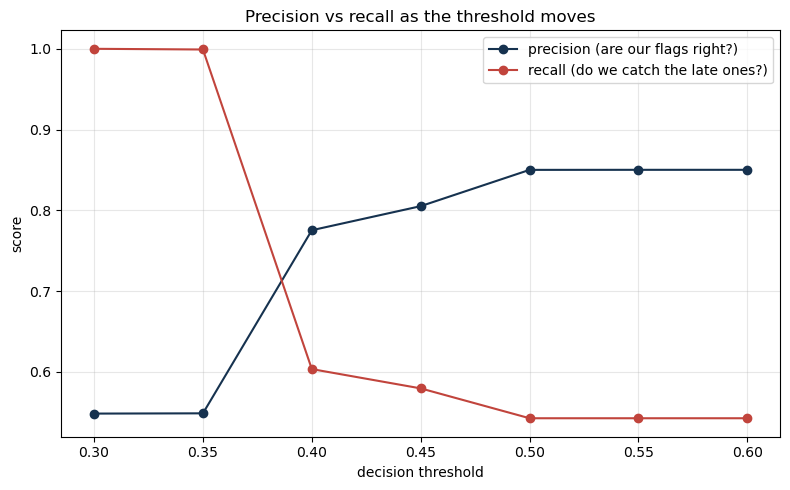

In [12]:
from sklearn.metrics import precision_score, recall_score

# how precision and recall shift as we move the decision threshold
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
precisions, recalls = [], []

for t in thresholds:
    flagged = (late_probability >= t).astype(int)
    precisions.append(precision_score(y_test, flagged))
    recalls.append(recall_score(y_test, flagged))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precisions, marker="o", label="precision (are our flags right?)", color="#16324F")
ax.plot(thresholds, recalls, marker="o", label="recall (do we catch the late ones?)", color="#C1443C")
ax.set_xlabel("decision threshold")
ax.set_ylabel("score")
ax.set_title("Precision vs recall as the threshold moves")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Model comparison

Benchmarking logistic regression against a decision tree and a random forest. All three land near 70%, which indicates the ceiling is set by the data rather than the model. Logistic regression is kept for being the simplest and most explainable.

In [13]:
from sklearn.ensemble import RandomForestClassifier

# random forest can capture patterns that a linear model misses
rf_model = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("random forest accuracy:", round(accuracy_score(y_test, rf_pred) * 100, 1), "%")
print()
print(confusion_matrix(y_test, rf_pred))

random forest accuracy: 65.4 %

[[11629  4679]
 [ 7808 11988]]


In [14]:
from sklearn.tree import DecisionTreeClassifier

# a single decision tree sits between logistic regression and random forest
# in complexity. max_depth limits how deep it grows, to prevent overfitting.
tree_model = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", DecisionTreeClassifier(max_depth=6, random_state=42))
])

tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

print("decision tree accuracy:", round(accuracy_score(y_test, tree_pred) * 100, 1), "%")
print("logistic regression was: 69.7 %")
print("random forest was:       65.4 %")

decision tree accuracy: 69.7 %
logistic regression was: 69.7 %
random forest was:       65.4 %


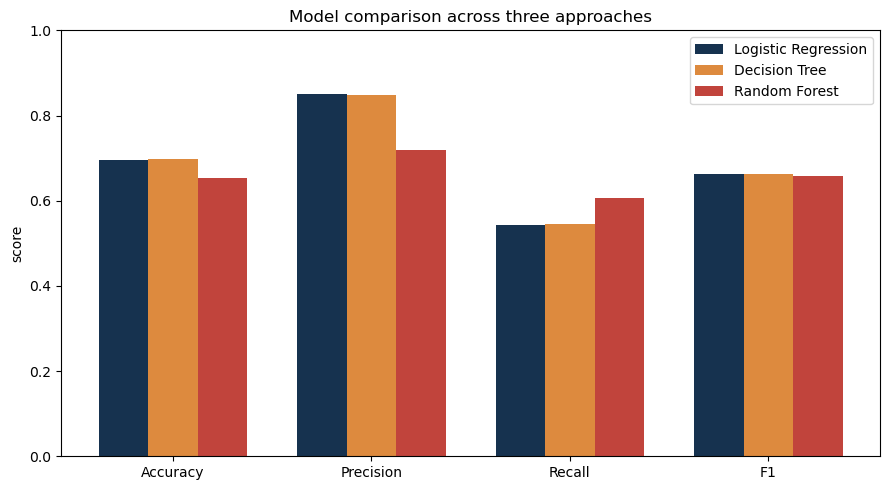

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# compare all three models on the same test set
models = {
    "Logistic Regression": y_pred,
    "Decision Tree": tree_pred,
    "Random Forest": rf_pred,
}

metrics = {}
for name, preds in models.items():
    metrics[name] = [
        accuracy_score(y_test, preds),
        precision_score(y_test, preds),
        recall_score(y_test, preds),
        f1_score(y_test, preds),
    ]

labels = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, metrics["Logistic Regression"], width, label="Logistic Regression", color="#16324F")
ax.bar(x,         metrics["Decision Tree"],       width, label="Decision Tree",       color="#DD8A3E")
ax.bar(x + width, metrics["Random Forest"],       width, label="Random Forest",       color="#C1443C")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("score")
ax.set_title("Model comparison across three approaches")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Conclusion

The model predicts late delivery at about 70% accuracy, well above the 55% base rate, using only order-time features. It independently confirms the dashboard finding: shipping mode is the dominant driver of lateness, with First Class the strongest risk signal.

Three model types (logistic regression, decision tree, random forest) all landed near 70%, indicating the data sets the ceiling. Logistic regression was chosen for being the simplest and most explainable.

**Business use:** flag high-risk orders at order time so the team can act before they ship. The decision threshold can be tuned to the business, lowering it to catch more late orders when intervention is cheap, raising it when false alarms are costly.